In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

In [3]:
SCRIPT_DIR_PATH = os.getcwd()
PARENT_DIR_PATH = os.path.dirname(SCRIPT_DIR_PATH)
DATA_DIR_PATH = os.path.join(PARENT_DIR_PATH, "data")
RAW_DATA_DIR_PATH = os.path.join(DATA_DIR_PATH, "raw_data")
PROCESSED_DATA_DIR_PATH = os.path.join(DATA_DIR_PATH, "processed_data")
CLIMATE_POLICY_DATA_DIR_PATH = os.path.join(RAW_DATA_DIR_PATH, "climate_policy_data")


In [4]:
emissions_df = pd.read_csv(os.path.join(PROCESSED_DATA_DIR_PATH, "historical_total_emission_per_country.csv"))
emissions_df.head()

,iso_alpha_3,year,total_emissions
0,ABW,1970,0.036970
1,ABW,1971,0.041825
2,ABW,1972,0.052708
3,ABW,1973,0.057704
4,ABW,1974,0.056999


## OECD Policy Stringency Index

In [5]:
oecd_df = pd.read_csv(os.path.join(CLIMATE_POLICY_DATA_DIR_PATH, "OECD.ECO.MAD,DSD_EPS@DF_EPS,1.0+all.csv"))
oecd_df.head()

,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,ACTION,REF_AREA,Reference area,FREQ,Frequency of observation,MEASURE,Measure,...,TIME_PERIOD,Time period,OBS_VALUE,Observation value,UNIT_MULT,Unit multiplier,UNIT_MEASURE,Unit of measure,DECIMALS,Decimals
0,DATAFLOW,OECD.ECO.MAD:DSD_EPS@DF_EPS(1.0),OECD Environmental Policy Stringency Index,I,AUS,Australia,A,Annual,POL_STRINGENCY,Policy stringency,...,1990,NaN,0.0,NaN,0,Units,0_TO_6,0-6 scale,2,Two
1,DATAFLOW,OECD.ECO.MAD:DSD_EPS@DF_EPS(1.0),OECD Environmental Policy Stringency Index,I,AUS,Australia,A,Annual,POL_STRINGENCY,Policy stringency,...,1991,NaN,0.0,NaN,0,Units,0_TO_6,0-6 scale,2,Two
2,DATAFLOW,OECD.ECO.MAD:DSD_EPS@DF_EPS(1.0),OECD Environmental Policy Stringency Index,I,AUS,Australia,A,Annual,POL_STRINGENCY,Policy stringency,...,1992,NaN,0.0,NaN,0,Units,0_TO_6,0-6 scale,2,Two
3,DATAFLOW,OECD.ECO.MAD:DSD_EPS@DF_EPS(1.0),OECD Environmental Policy Stringency Index,I,AUS,Australia,A,Annual,POL_STRINGENCY,Policy stringency,...,1993,NaN,0.0,NaN,0,Units,0_TO_6,0-6 scale,2,Two
4,DATAFLOW,OECD.ECO.MAD:DSD_EPS@DF_EPS(1.0),OECD Environmental Policy Stringency Index,I,AUS,Australia,A,Annual,POL_STRINGENCY,Policy stringency,...,1994,NaN,0.0,NaN,0,Units,0_TO_6,0-6 scale,2,Two


In [6]:
fields_to_keep =[
    "REF_AREA",
    "Climate policies",
    "TIME_PERIOD",
    "OBS_VALUE"
]

In [7]:
oecd_df_filtered = oecd_df[oecd_df["Climate policies"] == "All environmental policies (EPS index)"]
oecd_df_filtered = oecd_df_filtered[fields_to_keep]
oecd_df_filtered.head()

,REF_AREA,Climate policies,TIME_PERIOD,OBS_VALUE
8504,CHL,All environmental policies (EPS index),1990,0.0
8505,CHL,All environmental policies (EPS index),1991,0.0
8506,CHL,All environmental policies (EPS index),1992,0.0
8507,CHL,All environmental policies (EPS index),1993,0.0
8508,CHL,All environmental policies (EPS index),1994,0.0


In [8]:
# Rename columns for clarity
oecd_df_filtered.rename(columns={
    "REF_AREA": "iso_alpha_3",
    "TIME_PERIOD": "year",
    "OBS_VALUE": "policy_stringency_index"
}, inplace=True)

oecd_df_filtered.head()

,iso_alpha_3,Climate policies,year,policy_stringency_index
8504,CHL,All environmental policies (EPS index),1990,0.0
8505,CHL,All environmental policies (EPS index),1991,0.0
8506,CHL,All environmental policies (EPS index),1992,0.0
8507,CHL,All environmental policies (EPS index),1993,0.0
8508,CHL,All environmental policies (EPS index),1994,0.0


In [9]:
oecd_df_filtered.to_clipboard()

In [10]:
# how many unique iso3 codes?
oecd_df_filtered["iso_alpha_3"].nunique()

40

In [11]:
# min and max years
oecd_df_filtered["year"].min(), oecd_df_filtered["year"].max()

(np.int64(1990), np.int64(2020))

In [12]:
# Do all countries have data for all years?
expected_years = set(range(1990, 2020))
countries_with_missing_years = {}
for country in oecd_df_filtered["iso_alpha_3"].unique():
    years = set(oecd_df_filtered[oecd_df_filtered["iso_alpha_3"] == country]["year"])
    missing_years = expected_years - years
    if missing_years:
        countries_with_missing_years[country] = missing_years

countries_with_missing_years

{}

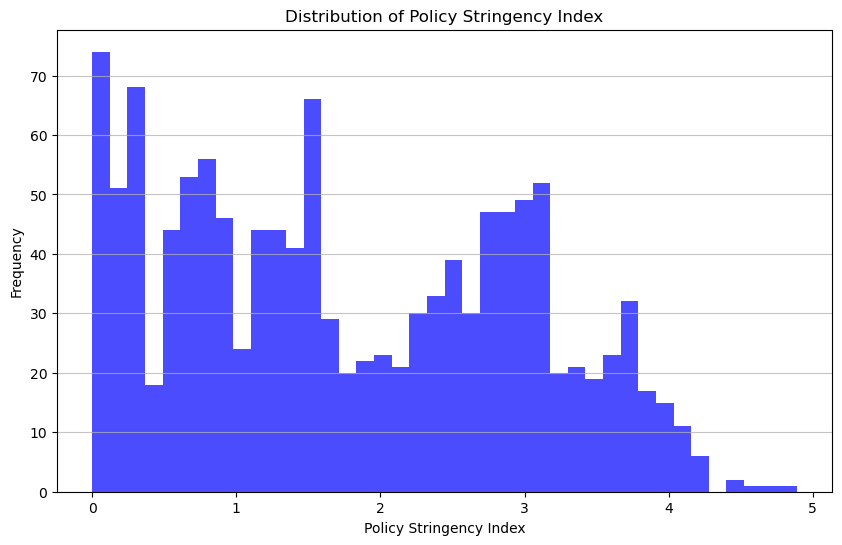

In [13]:
# Histogram of policy stringency index\
plt.figure(figsize=(10, 6))
plt.hist(oecd_df_filtered["policy_stringency_index"], bins=40, color='blue', alpha=0.7)
plt.title("Distribution of Policy Stringency Index")
plt.xlabel("Policy Stringency Index")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.75)
plt.show()

In [19]:
def plot_policy_time_series(country_iso3, df=oecd_df_filtered, year_col="year",
                            value_col="policy_stringency_index", y_label="Policy Stringency Index", figsize=(10, 6),
                            marker='o', title=None, show=True):
    """
    Plot policy stringency index time series for a given ISO3 country code.
    Returns (fig, ax) if data exists, otherwise returns None.
    """
    data = df[df["iso_alpha_3"] == country_iso3].sort_values(year_col)
    if data.empty:
        print(f"No data for {country_iso3}")
        return None

    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(data[year_col], data[value_col], marker=marker)
    ax.set_title(title or f"Policy Stringency Index Over Time for {country_iso3}")
    ax.set_xlabel("Year")
    ax.set_ylabel(y_label)
    ax.grid()
    if show:
        plt.show()
    return fig, ax

# Example usage:
# plot_policy_time_series("USA")

In [20]:
oecd_df_filtered["iso_alpha_3"].unique()

array(['CHL', 'ISL', 'ISR', 'MEX', 'SVN', 'CHN', 'RUS', 'GBR', 'USA',
       'AUS', 'BEL', 'CZE', 'IRL', 'JPN', 'KOR', 'POL', 'SVK', 'ITA',
       'DNK', 'EST', 'FIN', 'FRA', 'AUT', 'CAN', 'DEU', 'GRC', 'HUN',
       'LUX', 'NLD', 'NZL', 'NOR', 'PRT', 'ESP', 'SWE', 'CHE', 'TUR',
       'BRA', 'IND', 'IDN', 'ZAF'], dtype=object)

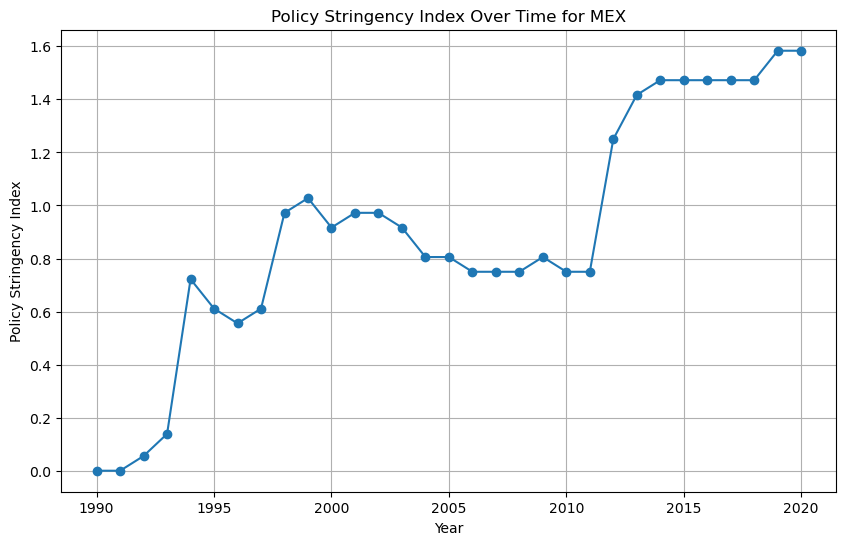

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Policy Stringency Index Over Time for MEX'}, xlabel='Year', ylabel='Policy Stringency Index'>)

In [21]:
plot_policy_time_series("MEX")

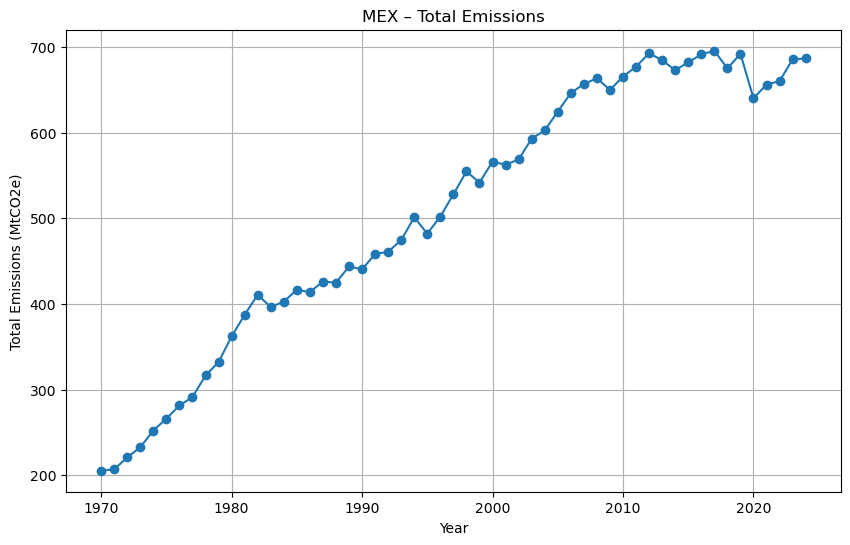

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'MEX – Total Emissions'}, xlabel='Year', ylabel='Total Emissions (MtCO2e)'>)

In [23]:
plot_policy_time_series(country_iso3="MEX", df=emissions_df, year_col="year",
                        value_col="total_emissions", title="MEX – Total Emissions",
                        y_label="Total Emissions (MtCO2e)")

In [62]:
merged_oecd_emissions_df = pd.merge(
    oecd_df_filtered,
    emissions_df,
    on=["iso_alpha_3", "year"],
    how="inner"
)
merged_oecd_emissions_df

,iso_alpha_3,Climate policies,year,policy_stringency_index,total_emissions
0,CHL,All environmental policies (EPS index),1990,0.000000,54.782461
1,CHL,All environmental policies (EPS index),1991,0.000000,53.334380
2,CHL,All environmental policies (EPS index),1992,0.000000,55.169696
3,CHL,All environmental policies (EPS index),1993,0.000000,57.666071
4,CHL,All environmental policies (EPS index),1994,0.000000,61.416301
...,...,...,...,...,...
1235,ZAF,All environmental policies (EPS index),2016,0.861111,582.204182
1236,ZAF,All environmental policies (EPS index),2017,0.861111,599.071597
1237,ZAF,All environmental policies (EPS index),2018,0.916667,600.392902
1238,ZAF,All environmental policies (EPS index),2019,0.861111,604.701921


In [63]:
merged_oecd_emissions_df.groupby("iso_alpha_3")["policy_stringency_index"].std().describe()


count    40.000000
mean      0.870857
std       0.308218
min       0.275432
25%       0.691184
50%       0.883109
75%       1.076464
max       1.496270
Name: policy_stringency_index, dtype: float64

In [ ]:
# log-transform emissions
y = np.log(merged_oecd_emissions_df["total_emissions"])
X_base = pd.get_dummies(
    merged_oecd_emissions_df[["iso_alpha_3", "year"]],
    drop_first=True
)
X_policy = pd.concat(
    [X_base, merged_oecd_emissions_df[["policy_stringency_index"]]],
    axis=1
)

In [74]:
from sklearn.model_selection import GroupKFold
from sklearn.metrics import root_mean_squared_error
from sklearn.linear_model import Ridge
import numpy as np

groups = merged_oecd_emissions_df["iso_alpha_3"]
cv = GroupKFold(n_splits=5)

rmse_base, rmse_policy = [], []

for train, test in cv.split(X_base, y, groups):
    m0 = Ridge(alpha=1.0).fit(X_base.iloc[train], y.iloc[train])
    m1 = Ridge(alpha=1.0).fit(X_policy.iloc[train], y.iloc[train])

    rmse_base.append(
        root_mean_squared_error(y.iloc[test], m0.predict(X_base.iloc[test]))
    )
    rmse_policy.append(
        root_mean_squared_error(y.iloc[test], m1.predict(X_policy.iloc[test]))
    )

print("Base Error:", np.mean(rmse_base))
print("With Policy Error:", np.mean(rmse_policy))


Base Error: 1.6342838821675527
With Policy Error: 1.63585370891836


In [71]:
from sklearn.inspection import permutation_importance

model = Ridge(alpha=1.0).fit(X_policy, y)

perm = permutation_importance(
    model,
    X_policy,
    y,
    n_repeats=20,
    random_state=0
)

importance = pd.Series(
    perm.importances_mean,
    index=X_policy.columns
).sort_values(ascending=False)

importance["policy_stringency_index"]


np.float64(0.006797386204025235)

In [75]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=0
)

rmse_base, rmse_policy = [], []

for train, test in cv.split(X_base, y, groups):
    xgb.fit(X_base.iloc[train], y.iloc[train])
    rmse_base.append(
        root_mean_squared_error(y.iloc[test], xgb.predict(X_base.iloc[test]))
    )

    xgb.fit(X_policy.iloc[train], y.iloc[train])
    rmse_policy.append(
        root_mean_squared_error(y.iloc[test], xgb.predict(X_policy.iloc[test]))
    )

print("Base Error:", np.mean(rmse_base))
print("With Policy Error:", np.mean(rmse_policy))


Base Error: 1.6565176174346352
With Policy Error: 1.659980741869513


/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


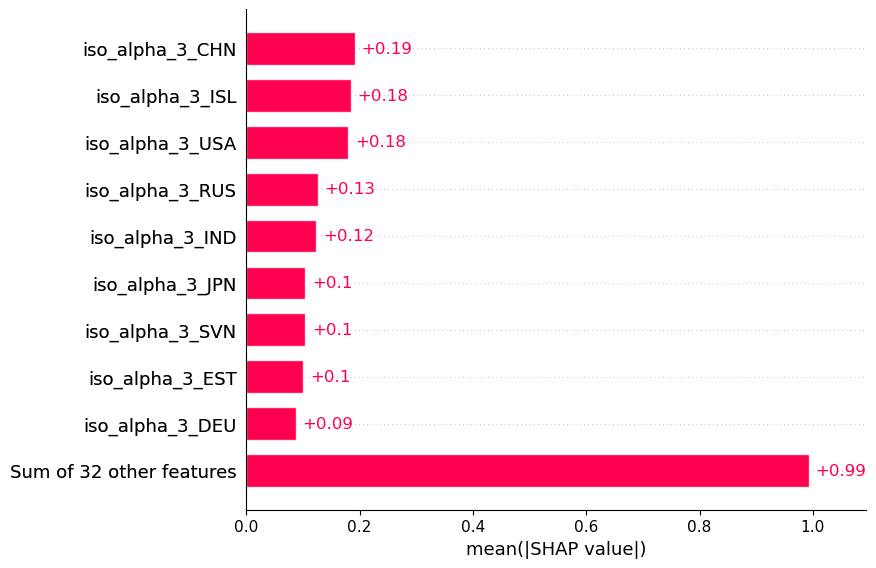

In [73]:
import shap
explainer = shap.Explainer(xgb)
shap_values = explainer(X_policy.sample(1000))
shap.plots.bar(shap_values)
